In [21]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from matplotlib.axes._axes import _log as  matplotlib_axes_logger
from mpl_toolkits import mplot3d
import seaborn as sns 
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split

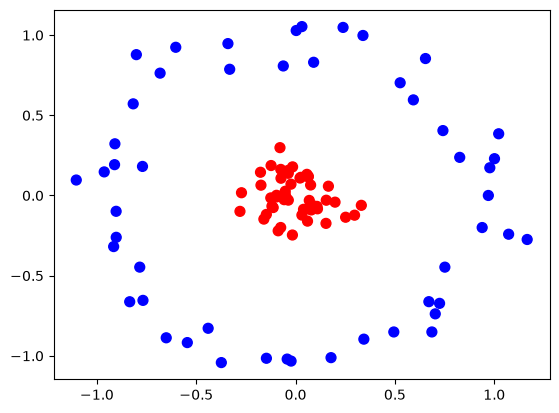

In [22]:
from sklearn.datasets._samples_generator import make_circles
x , y = make_circles(100 , factor = .1, noise = 0.1)
plt.scatter(x[:,0] , x[:,1], c= y , s = 50 , cmap= 'bwr')

applying normal vs kernel svm and noting down the differences 


In [23]:
x_train , x_test , y_train , y_test = train_test_split( x, y , test_size = 0.2 )

In [24]:
classifier = SVC(kernel = 'linear')
classifier.fit(x_train ,y_train)
y_pred = classifier.predict(x_test)

In [25]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pred)

0.3

In [28]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(x, y, clf):
    x_set, y_set = x, y
    X1, X2 = np.meshgrid(np.arange(start = x_set[:, 0].min() - 1, 
                                 stop = x_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = x_set[:, 1].min() - 1, 
                                 stop = x_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_63655/1873389037.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


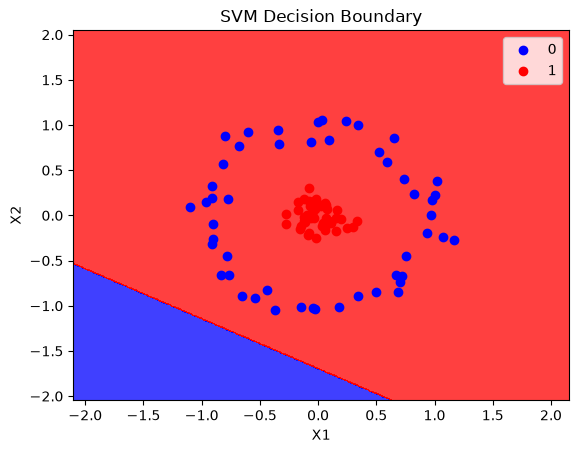

In [29]:
plot_decision_boundary(x, y, classifier)

In [ ]:
def plot_3d_plot(x ,y):
    r = np.exp(-(x**2).sum(1)) #sum gives the sum of the both coordinates which is equal to the z coordinate for those points
    ax = plt.subplot(projection = '3d')
    ax.scatter3D(x[:, 0] , x[:,1] , r , c=y , s = 100 , cmap = 'bwr')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='x1', ylabel='x2', zlabel='y'>

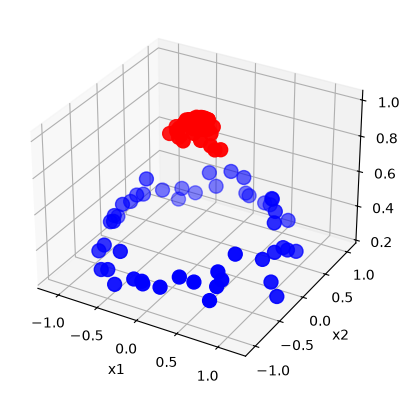

In [33]:
plot_3d_plot(x , y)

In [34]:
rbf_classifier = SVC(kernel = "rbf")
rbf_classifier.fit(x_train , y_train)
y_pred1 = rbf_classifier.predict(x_test)


In [36]:
accuracy_score(y_test , y_pred1)

1.0

/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_63655/1873389037.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


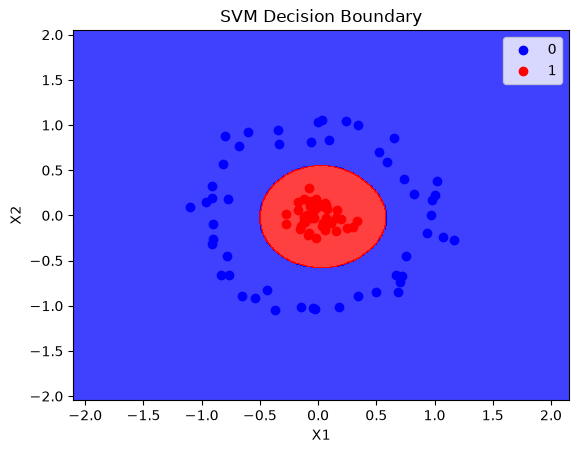

In [38]:
plot_decision_boundary(x , y, rbf_classifier)

In [42]:
poly_classifier = SVC(kernel = "poly" , degree =2) 
poly_classifier.fit(x_train , y_train)
y_pred2  =poly_classifier.predict(x_test)



In [43]:
accuracy_score(y_test , y_pred2)

1.0

/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_63655/1873389037.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1],


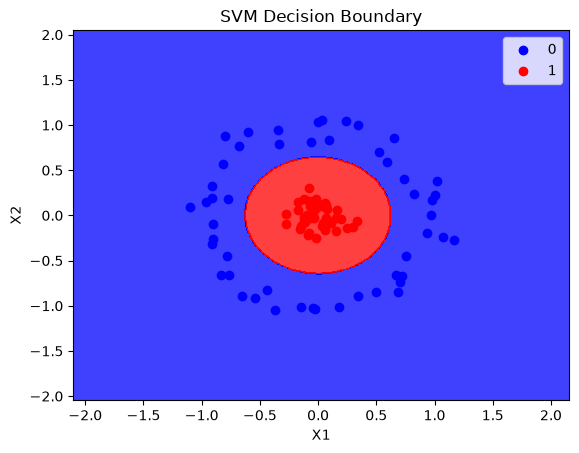

In [44]:
plot_decision_boundary(x , y, poly_classifier)